# Compass Serial Recordings

In [12]:
from pathlib import Path
import re

import matplotlib.pyplot as plt

TEXT_FILES = sorted(Path.cwd().glob("*.txt"))
print(f"Found {len(TEXT_FILES)} text file(s):")
for path in TEXT_FILES:
    print(f"  {path.name}")

Found 1 text file(s):
  serial_output.txt


In [13]:
LABELS = {
    "Quaternion": ["qw", "qx", "qy", "qz"],
    "Magnetometer": ["mx", "my", "mz"],
    "Accelerometer": ["ax", "ay", "az"],
    "Gyroscope": ["gx", "gy", "gz"],
}

NUMBER = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")


def parse_file(path):
    samples = []
    sample = {}

    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.startswith("Quaternion:"):
            if sample:
                samples.append(sample)
            values = [float(value) for value in NUMBER.findall(line)]
            sample = dict(zip(LABELS["Quaternion"], values))
        elif line.startswith("yaw:"):
            values = [float(value) for value in NUMBER.findall(line)]
            sample.update(dict(zip(["yaw", "pitch", "roll"], values)))
        elif line.startswith("Magnetometer:"):
            values = [float(value) for value in NUMBER.findall(line)]
            sample.update(dict(zip(LABELS["Magnetometer"], values)))
        elif line.startswith("Accelerometer:"):
            values = [float(value) for value in NUMBER.findall(line)]
            sample.update(dict(zip(LABELS["Accelerometer"], values)))
        elif line.startswith("Gyroscope:"):
            values = [float(value) for value in NUMBER.findall(line)]
            sample.update(dict(zip(LABELS["Gyroscope"], values)))
            if len(sample) == 16:
                samples.append(sample)
                sample = {}

    return samples


parsed_files = {path: parse_file(path) for path in TEXT_FILES}
for path, samples in parsed_files.items():
    print(f"{path.name}: {len(samples)} samples")

serial_output.txt: 496 samples


serial_output.txt: plotted 496 samples


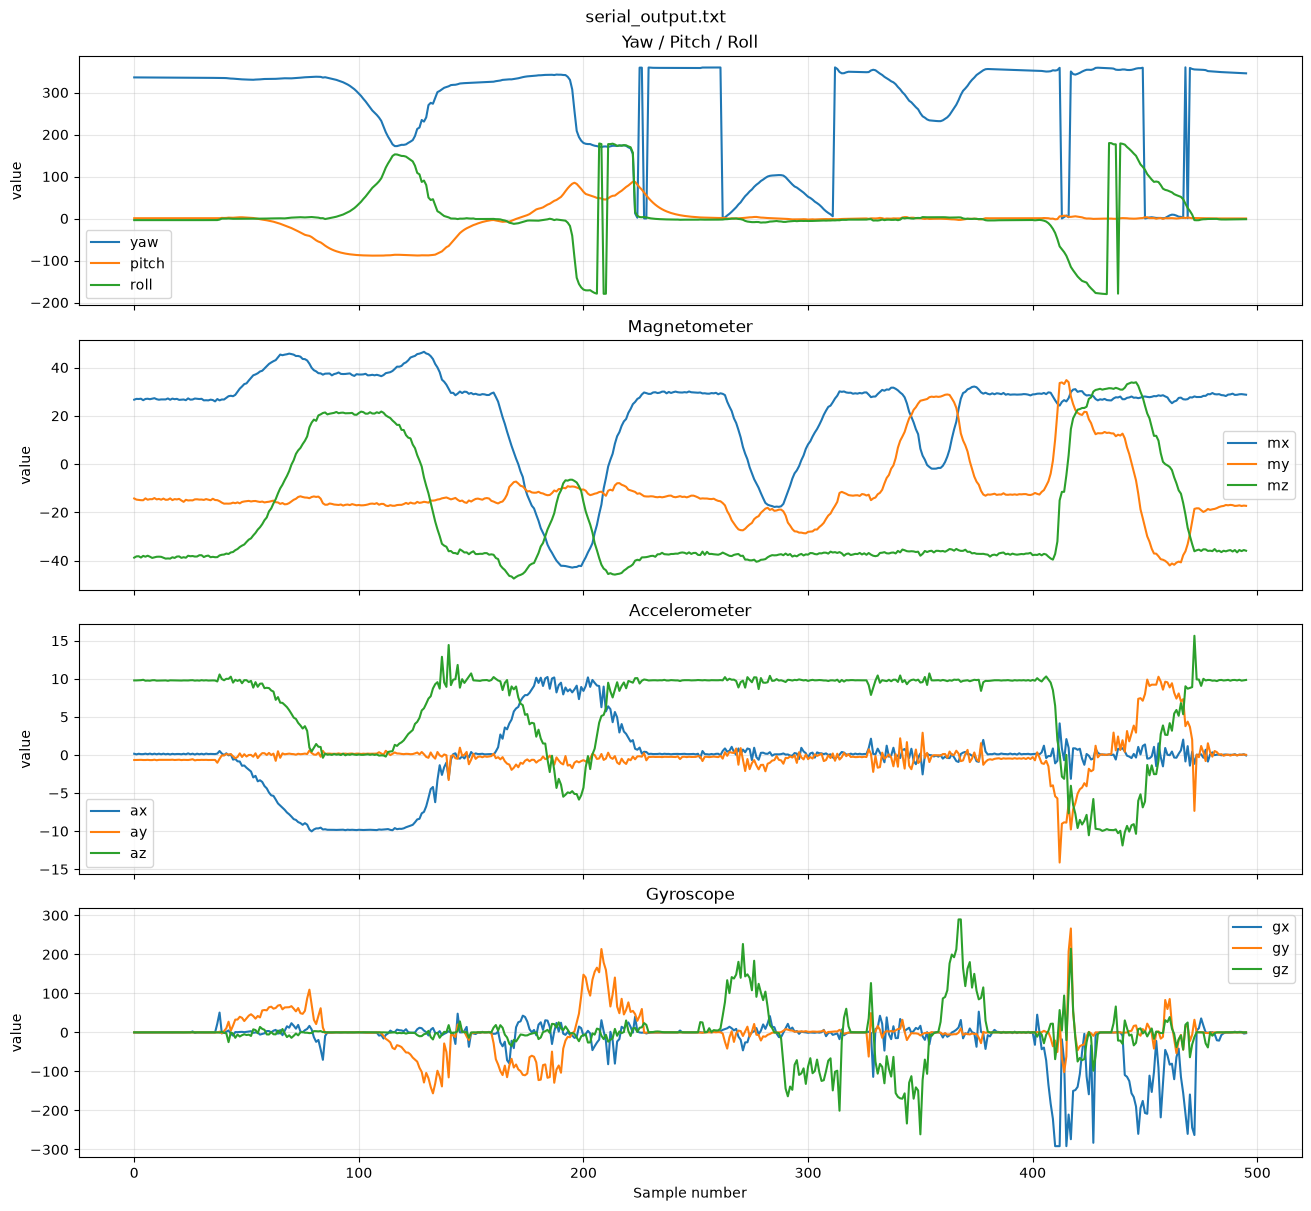

In [14]:
PLOT_GROUPS = {
    "Yaw / Pitch / Roll": ["yaw", "pitch", "roll"],
    "Magnetometer": ["mx", "my", "mz"],
    "Accelerometer": ["ax", "ay", "az"],
    "Gyroscope": ["gx", "gy", "gz"],
}


def plot_file(path, records):
    if not records:
        print(f"{path.name}: no complete samples found")
        return

    x = range(len(records))
    figure, axes = plt.subplots(
        len(PLOT_GROUPS),
        1,
        sharex=True,
        figsize=(13, 12),
        constrained_layout=True,
    )
    for axis, (title, columns) in zip(axes, PLOT_GROUPS.items()):
        for column in columns:
            axis.plot(x, [row[column] for row in records], label=column)
        axis.set_title(title)
        axis.set_ylabel("value")
        axis.grid(True, alpha=0.3)
        axis.legend()
    axes[-1].set_xlabel("Sample number")
    figure.suptitle(path.name)
    print(f"{path.name}: plotted {len(records)} samples")
    plt.show()


for text_file, records in parsed_files.items():
    plot_file(text_file, records)